# Deep Learning Project - CLIP Visual grounding - External Attention & FastRCNN

# 0 - Imports

In these first sections we will cover installations of all libraries taking into account the platform in which this notebook will be executed

-------------

## 0.1 Colab Setting

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Put your Colab-only code here
    print("Running on Google Colab")
    !pip install ftfy regex tqdm
    !pip install git+https://github.com/openai/CLIP.git
    !pip install torchmetrics
    !pip3 install torch torchvision torchaudio
    !pip install -U ultralytics
else:
    print("Not running on Google Colab")


Not running on Google Colab


In [2]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Put your Colab-only code here
    print("Running on Google Colab")
    !mkdir dataset
    !gdown 1A_ezza3Bj3OJv8wgTyIsLynNqqztRwl4
    !ls
    !mv Uploaded_refcocog.tar.gz ./dataset/
    !ls dataset
else:
    print("Not running on Google Colab")


Not running on Google Colab


## 0.2 Imports

In [3]:
import pickle # Load refs and annotations
import json
import os
import pandas as pd
import numpy as np
import pprint
import json
import cv2
import random
import heapq
from __future__ import  absolute_import
import os
from collections import namedtuple
import time

from typing import Any, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.utils.tensorboard import SummaryWriter
from torch.cuda.amp import autocast

import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import v2
from torchvision.ops import roi_align
from torchvision.utils import draw_bounding_boxes
from torchvision import models
import torchmetrics

import pytorch_lightning as pl
from pytorch_lightning.utilities.types import STEP_OUTPUT

from transformers import T5Tokenizer, T5ForConditionalGeneration
from transformers import CLIPProcessor, CLIPModel

from tqdm.notebook import tqdm, trange
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import clip
from ultralytics import YOLO
from PIL import Image, ImageDraw
from tabulate import tabulate

from ipywidgets import FloatProgress
import math
from torch.nn.modules.batchnorm import _BatchNorm
from torchvision.ops import box_convert
from torchvision.ops import nms
from torchvision.ops import RoIPool

## 0.3 Tensorboard and Metrics

In [4]:
%load_ext tensorboard

In [5]:
if torch.cuda.is_available():
    print("CUDA backend is available.")
    device = torch.device('cuda')
else:
    print("Neither CUDA or MPS backend are available. Resorting to CPU")
    device = torch.device('cpu')

Neither CUDA or MPS backend are available. Resorting to CPU


In [6]:
log_dir = 'logs'

# 1 - Utils

## 1.1 Helper Functions and Cells

The `plot_images` function displays a list of images in a grid. Used only for displaying purposes

In [7]:
def plot_images(images):
    
    num_images = len(images)
    cols = 3  # Number of columns in the grid
    rows = (num_images // cols) + (num_images % cols > 0)

    # Create a figure to display the images
    plt.figure(figsize=(15, 5 * rows))

    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')  # Hide axes

    plt.show()

In [8]:
def draw_bboxes(image_path, bbox, gt, confidence):
    image = cv2.imread(image_path)

    # Define colors
    max_bbox_color = (0, 255, 0)  # Green for ground truth
    other_bbox_color = (0, 0, 255)  # Red for predictions

    # Plot all bboxes
    cv2.rectangle(image, (int(bbox[0]), int(bbox[1])) ,(int(bbox[2]), int(bbox[3])), other_bbox_color, 2)
    cv2.putText(image, 'Confidence' + str(confidence), (int(bbox[0]), int(bbox[1])-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, other_bbox_color, 2)
    color = max_bbox_color
    cv2.rectangle(image, (int(gt[0]), int(gt[1])) ,(int(gt[2]), int(gt[3])), color, 2)

    # Convert the image from BGR to RGB for displaying with matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image_rgb

In [9]:
def plot_images_case(cases):
    images = []

    for i, case in enumerate(cases):
        image_path = os.path.join('', case["path"])
        ground_truth=case["ground_truth"]
        candidate=case["candidate"]
        confidence= case['confidence']
        images.append(draw_bboxes(image_path,candidate,ground_truth,confidence))

    num_images = len(images)
    cols = 3  # Number of columns in the grid
    rows = (num_images // cols) + (num_images % cols > 0)

    # Create a figure to display the images
    plt.figure(figsize=(15, 5 * rows))

    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')  # Hide axes

    plt.show()

'draw_bboxes' is used to confront the extracted `bbox` with the relative `ground_truth`

function to compute the Intersection Over Union of two different bboxes

In [10]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection_area = max(0, x2 - x1 + 1) * max(0, y2 - y1 + 1) # +1 to avoid max(0,0) therefore avoiding

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = box1_area + box2_area - intersection_area

    return intersection_area / union_area

In [11]:
def getcaption(elem):
    li = []
    for e in elem["sentences"]:
        li.append(e['raw'])
    return li

In [13]:
with open("../refcocog/annotations/refs(umd).p", "rb") as fp:
  refs = pickle.load(fp)

# 'annotations' will be a dict object mapping the 'annotation_id' to the 'bbox' to make search faster
with open("../refcocog/annotations/instances.json", "rb") as fp:
  data = json.load(fp)
  annotations = dict(sorted({ann["id"]: ann["bbox"] for ann in data["annotations"]}.items()))

In [14]:
def tonumpy(data):
    if isinstance(data, np.ndarray):
        return data
    if isinstance(data, torch.Tensor):
        return data.detach().cpu().numpy()


def totensor(data, cuda=False):
    if isinstance(data, np.ndarray):
        tensor = torch.from_numpy(data)
    if isinstance(data, torch.Tensor):
        tensor = data.detach()
    if cuda:
        tensor = tensor.cuda()
    return tensor


def scalar(data):
    if isinstance(data, np.ndarray):
        return data.reshape(1)[0]
    if isinstance(data, torch.Tensor):
        return data.item()

## 1.2 MetricMeter

Class to help track down examples duting runs

In [58]:
import os
import heapq
import numpy as np
import pickle
import torch
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt

class MetricMeter:
    def __init__(
        self,
        name="Default",
        threshold=0.5,
        log_dir='./logs/default_run',
        save_dir='./metrics',
        mAP_iou_thresholds=[0.5, 0.75, 0.9],  # IoU thresholds for mAP
        conf_threshold_cm=0.5  # Confidence threshold for confusion matrix
    ):
        self.name = name
        self.threshold = threshold
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)

        self.epoch = 0
        self.writer = SummaryWriter(log_dir=log_dir)
        self.reset()

        # Metrics configuration
        self.mAP_iou_thresholds = mAP_iou_thresholds
        self.conf_threshold_cm = conf_threshold_cm

        # Heaps for best/worst cases
        self.best_cases_iou = []
        self.worst_cases_iou = []
        self.best_cases_sim = []
        self.worst_cases_sim = []

    def reset(self):
        self.count = 0
        self.iou = 0
        self.correct_bboxes = 0
        self.semantic = 0
        self.metrics = []
        
        # Lists to track metrics
        self.iou_list = []
        self.precision_list = []
        self.recall_list = []
        self.soft_iou_list = []
        self.confidences = []
        
        # For mAP and confusion matrix
        self.all_confidences = []
        self.all_ious = []

    def _update_heap(self, heap, item, max_size, key='iou', reverse=False):
        item_value = item[key]
        heap_value = -item_value if reverse else item_value

        if len(heap) < max_size:
            heapq.heappush(heap, (heap_value, item))
        else:
            if heap_value > heap[0][0]:
                heapq.heappushpop(heap, (heap_value, item))

    def update(self, iou, confidence, filename, bbox_e, bbox_gt):
        try:
            self.count += 1
            self.iou += iou
            self.iou_list.append(iou)
            self.confidences.append(confidence)
            self.all_confidences.append(confidence)
            self.all_ious.append(iou)

            if iou >= self.threshold:
                self.correct_bboxes += 1
            self.semantic += confidence

            # Soft IoU calculation
            soft_iou = iou * confidence
            self.soft_iou_list.append(soft_iou)

            # Precision and recall
            precision = 1 if iou >= self.threshold else 0
            recall = 1 if iou >= self.threshold else 0
            self.precision_list.append(precision)
            self.recall_list.append(recall)

            item = {
                'iou': iou,
                'confidence': confidence,
                'ground_truth': bbox_gt,
                'candidate': bbox_e,
                'path': filename
            }

            # Update heaps (fixed key typo: 'ioupl' -> 'iou')
            self._update_heap(self.best_cases_iou, item, max_size=5, key='iou', reverse=False)
            self._update_heap(self.worst_cases_iou, item, max_size=5, key='iou', reverse=True)
            self._update_heap(self.best_cases_sim, item, max_size=5, key='confidence', reverse=False)
            self._update_heap(self.worst_cases_sim, item, max_size=5, key='confidence', reverse=True)
        except Exception as e:
            print(e)

    def compute_ap(self, iou_threshold):
        """Compute Average Precision (AP) for a single IoU threshold."""
        if not self.all_confidences:
            return 0.0

        # Sort by confidence descending
        sorted_indices = np.argsort(-np.array(self.all_confidences))
        sorted_ious = np.array(self.all_ious)[sorted_indices]
        
        # TPs and FPs
        tp = (sorted_ious >= iou_threshold).astype(float)
        fp = (sorted_ious < iou_threshold).astype(float)
        
        # Cumulative sums
        tp_cumsum = np.cumsum(tp)
        fp_cumsum = np.cumsum(fp)
        
        # Precision and recall
        precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-6)
        recalls = tp_cumsum / (sum(tp) + 1e-6)  # Total positives
        
        # AP via interpolation (area under PR curve)
        ap = 0.0
        for r in np.arange(0, 1.01, 0.01):
            prec_at_r = precisions[recalls >= r]
            p = prec_at_r.max() if prec_at_r.size > 0 else 0
            ap += p / 101
        
        return ap

    def new_epoch(self, tag):
        self.epoch += 1

        # Existing metrics
        mean_iou = np.mean(self.iou_list) if self.iou_list else 0
        mean_soft_iou = np.mean(self.soft_iou_list) if self.soft_iou_list else 0
        precision = np.mean(self.precision_list) if self.precision_list else 0
        recall = np.mean(self.recall_list) if self.recall_list else 0
        grounding_accuracy = self.correct_bboxes / self.count if self.count > 0 else 0
        semantic_similarity = self.semantic / self.count if self.count > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall + 1e-6)

        # Compute mAP
        mAP = 0.0
        aps = []
        if self.all_confidences and self.all_ious:
            for thresh in self.mAP_iou_thresholds:
                ap = self.compute_ap(thresh)
                aps.append(ap)
            mAP = np.mean(aps)

        # Log mAP and APs
        self.writer.add_scalar('mAP', mAP, self.epoch)
        for i, thresh in enumerate(self.mAP_iou_thresholds):
            self.writer.add_scalar(f'AP@{thresh}', aps[i], self.epoch)

        # Confusion Matrix
        tp, fp, fn, tn = 0, 0, 0, 0
        for c, i in zip(self.all_confidences, self.all_ious):
            if c >= self.conf_threshold_cm and i >= self.threshold:
                tp += 1
            elif c >= self.conf_threshold_cm and i < self.threshold:
                fp += 1
            elif c < self.conf_threshold_cm and i >= self.threshold:
                fn += 1
            else:
                tn += 1

        # Log confusion matrix as figure
        cm = np.array([[tp, fp], [fn, tn]])
        fig = plt.figure()
        plt.imshow(cm, cmap='Blues')
        plt.colorbar()
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.xticks([0, 1], ['Positive', 'Negative'])
        plt.yticks([0, 1], ['Positive', 'Negative'])
        plt.title(f'Confusion Matrix (Conf Threshold={self.conf_threshold_cm})')
        self.writer.add_figure('Confusion Matrix', fig, self.epoch)
        plt.close(fig)

        # Log existing metrics
        self.writer.add_scalar('Mean IoU', mean_iou, self.epoch)
        self.writer.add_scalar('Soft IoU', mean_soft_iou, self.epoch)
        self.writer.add_scalar('Precision', precision, self.epoch)
        self.writer.add_scalar('Recall', recall, self.epoch)
        self.writer.add_scalar('F1-Score', f1_score, self.epoch)
        self.writer.add_scalar('Grounding Accuracy', grounding_accuracy, self.epoch)
        self.writer.add_scalar('Semantic Similarity', semantic_similarity, self.epoch)

        # Save epoch data
        def serialize_case(case):
            return {
                'iou': float(case['iou']),
                'confidence': float(case['confidence']),
                'ground_truth': case['ground_truth'].tolist() if isinstance(case['ground_truth'], torch.Tensor) else case['ground_truth'],
                'candidate': case['candidate'].tolist() if isinstance(case['candidate'], torch.Tensor) else case['candidate'],
                'path': case['path']
            }

        epoch_data = {
            'epoch': self.epoch,
            'metrics': {
                'mean_iou': mean_iou,
                'soft_iou': mean_soft_iou,
                'precision': precision,
                'recall': recall,
                'f1_score': f1_score,
                'grounding_accuracy': grounding_accuracy,
                'semantic_similarity': semantic_similarity,
                'mAP': mAP,
                'APs': {f'AP@{thresh}': ap for thresh, ap in zip(self.mAP_iou_thresholds, aps)},
                'confusion_matrix': cm.tolist()
            },
            'best_cases_iou': [serialize_case(item[1]) for item in sorted(self.best_cases_iou, key=lambda x: x[0], reverse=True)],
            'worst_cases_iou': [serialize_case(item[1]) for item in sorted(self.worst_cases_iou, key=lambda x: x[0])],
            'best_cases_sim': [serialize_case(item[1]) for item in sorted(self.best_cases_sim, key=lambda x: x[0], reverse=True)],
            'worst_cases_sim': [serialize_case(item[1]) for item in sorted(self.worst_cases_sim, key=lambda x: x[0])]
        }

        with open(os.path.join(self.save_dir, f'metrics_epoch_{self.epoch}_{tag}.pkl'), 'wb') as f:
            pickle.dump(epoch_data, f)

        self.reset()

# 2 - Data Preparation and Augmentation

In [59]:
def denormalize(image, mean, std):
    mean = torch.tensor(mean).reshape(1, 1, 3).to(device)  # Reshape to match (H, W, C)
    std = torch.tensor(std).reshape(1, 1, 3).to(device)
    image = image.to(device)
    denormalized_image = image * std + mean
    return denormalized_image

class Denormalize:
    def __init__(self):
        clip_mean = [0.48145466, 0.4578275, 0.40821073]
        clip_std = [0.26862954, 0.26130258, 0.27577711]
        self.mean = torch.tensor(clip_mean).reshape(-1, 1, 1)  # Adjust shape to (H, W, C)
        self.std = torch.tensor(clip_std).reshape(-1, 1, 1)

    def __call__(self, tensor):
        # Denormalize the image tensor
        denormalized_tensor = tensor * self.std + self.mean
        return denormalized_tensor

In [60]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]


In [61]:
class DataAugmentation():
# This class is used to perform tranformation in order to have augmented data

    def blur(self,img,bbox):
        # Gaussian Blur the image
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.GaussianBlur(kernel_size=5),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox

    def rotate(self,img,bbox):
        # Rotate the image
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.RandomRotation(degrees=20),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox

    def grayscale(self,img,bbox):
        # Convert the image to grayscale
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Grayscale(num_output_channels=3),
            v2.ToTensor(),
            # since we do another manipulation we compute again the normalization
            # of the image even tho clip does it before
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox

    def colorrand(self,img,bbox):
        # Randomly change the color of the image
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.ColorJitter(brightness=0.01*random.randrange(1,50), contrast=0.01*random.randrange(1,50), saturation=0.01*random.randrange(1,50), hue=0.01*random.randrange(1,50)),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox

    def Hflip(self,img,bbox):
        # flip horizontally both image and bbox
        #img = v2.functional.hflip(img)
        cxcywh_format = box_convert(bbox, 'xyxy', 'cxcywh')

        # flip the y coordinate
        transform = v2.Compose([
            v2.PILToTensor(),
            #Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.RandomHorizontalFlip(p=1),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        cxcywh_format[0] = img.shape[2] - cxcywh_format[0]

        bbox = box_convert(cxcywh_format, 'cxcywh', 'xyxy')
        return img, bbox

    def random_augmentation(self,img,bbox):
        # Randomly choose a transformation to be applied to the image
        img = img.to("cpu")
        n = random.randint(0, 4)
        if n == 0:
            return DataAugmentation.blur(self,img,bbox)
        elif n == 1:
            return DataAugmentation.Hflip(self,img,bbox)
        elif n == 2:
            return DataAugmentation.grayscale(self,img,bbox)
        elif n == 3:
            return DataAugmentation.colorrand(self,img,bbox)
        else:
            return DataAugmentation.Hflip(self,img,bbox)

In [62]:
clip_model, clip_preprocess = clip.load("RN50", device=device)

In [63]:
class RefCOCOG(Dataset):
    """
    Args:
        The dataset will be the raw data wothput any tipe of preprocessing
        {
            'file_name':
            'caption':
            'ann_id': needed to extract the relative bbox from the .json file
            'bbox': values are set like following:
                - x
                - y
                - width
                - height
        }
    """
    def __init__(self, refs, model, preprocess, annotations, split="train", device = 'cuda', count = 8000):

        self.clip_model, self.clip_preprocess = model, preprocess
        self.device = device
        #self.images = []
        self.raws = []
        self.texts = []
        self.filepaths =[]
        self.gt = []
        self.cls = []
        self.AUG = DataAugmentation()
        self.split = split


        temp = 0
        for elem in [d for d in refs if d["split"]==split]:

            # Retrieve Single image
            file_name = os.path.join("../refcocog/images/", f'{"_".join(elem["file_name"].split("_")[:3])}.jpg')
            #image = Image.open(file_name)

            # Retrieve possible ground truth measures
            cls = elem['category_id']
            gt = annotations[elem['ann_id']]
            bbox_tnsor = torch.tensor(gt, device=self.device)
            new_bbox = box_convert(bbox_tnsor, 'xywh', 'xyxy')

            # Get all texts related to the picture
            sentences = elem['sentences']

            self.raws.append(sentences[0]['raw'])
            self.texts.append(clip.tokenize(sentences[0]['raw']))
            #self.images.append(self.clip_preprocess(image))
            self.gt.append(new_bbox)
            self.cls.append(cls)
            self.filepaths.append(file_name)
            temp += 1
            if (temp > count):
                break

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        
        raw = self.raws[idx]
        text = self.texts[idx]
        #images = self.images[idx]
        gt = self.gt[idx]
        cls = self.cls[idx]
        filename = self.filepaths[idx]
        image = Image.open(filename)
        original_height = image.size[1]
        #self.clip_preprocess(image)
        # Apply augmentations
        image = self.clip_preprocess(image).to(device)
        if(self.split=='train'):
            image, gt = self.AUG.random_augmentation(image,gt)
        processed_height = image.size(-2)



        scale = processed_height / original_height

        #image = self.clip_preprocess(image).to(device)
        return raw, text, gt, cls, filename, image, scale

    def __call__(self, idx):
        print(json.dumps(self.dataset[idx], indent=4))


In [64]:
count = 16 * 4

In [77]:
# create dataset and dataloader
print("----------------------Processing train split----------------------------")
dataset_train = RefCOCOG(refs, clip_model, clip_preprocess, annotations, device=device, count=count, split="train")
dataloader_train = DataLoader(dataset_train, batch_size=8)
len_train = len(dataset_train)
print(f"Numero esempi in train = {len_train}")

print("----------------------Processing test split-----------------------------")
dataset_test = RefCOCOG(refs, clip_model, clip_preprocess, annotations, device=device,count=count, split="test")
dataloader_test = DataLoader(dataset_test, batch_size=8)
len_test = len(dataset_test)
print(f"Numero esempi in test = {len_test}")

print("----------------------Processing eval split-----------------------------")
dataset_eval = RefCOCOG(refs, clip_model, clip_preprocess, annotations, device=device,count=64, split="val")
dataloader_eval = DataLoader(dataset_eval, batch_size=8)
len_eval = len(dataset_eval)
print(f"Numero esempi in eval = {len_eval}")

print("------------------------------------------------------------------------")


----------------------Processing train split----------------------------
Numero esempi in train = 65
----------------------Processing test split-----------------------------
Numero esempi in test = 65
----------------------Processing eval split-----------------------------
Numero esempi in eval = 65
------------------------------------------------------------------------


In [78]:
images = []
for raw, text, gt, cls, filename, image, scale in dataloader_eval:
    images = image
    break

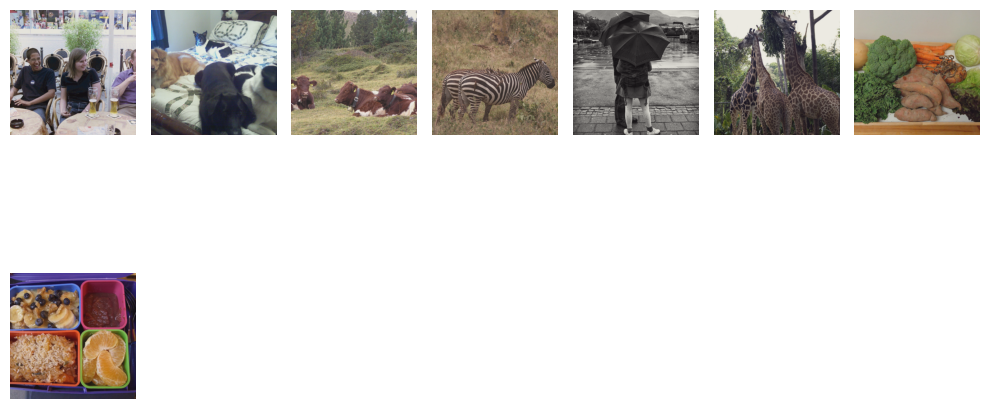

In [79]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Calculate the number of rows needed to display images in a 2-column layout
num_images = len(images)
num_cols = 7
num_rows = (num_images + num_cols - 1) // num_cols  # Ceiling division to get the required number of rows

# Set up the plot
plt.figure(figsize=(10, num_rows * 3))  # Adjust the figure size as needed

# Loop through and display each processed image in a grid with denormalization
for i, img in enumerate(images):
    # Denormalize the image
    img = img.permute(1, 2, 0)  # Convert (C, H, W) to (H, W, C)
    img = denormalize(img, mean, std)  # Apply denormalization
    img = torch.clip(img, 0, 1)  # Clip to valid range [0, 1] and convert to numpy for display
    img = img.cpu()
    # Add subplot in a 2-column grid
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(img)
    plt.axis('off')  # Hide the axis

# Show the plot with all processed images
plt.tight_layout()
plt.show()

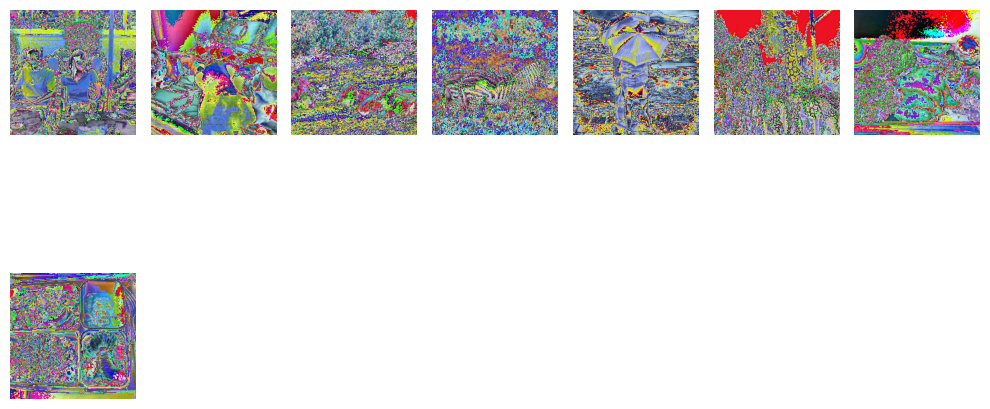

In [80]:
# Set up the plot
plt.figure(figsize=(10, num_rows * 3)) 

# Loop through and display each processed image
for i, img in enumerate(images):
    # Check if the image is a tensor and convert it to a NumPy array if needed
    if isinstance(img, torch.Tensor):
        img = img.permute(1, 2, 0).cpu().numpy()  # Convert (C, H, W) to (H, W, C)
        img = (img * 255).astype('uint8')  # Convert to [0, 255] range for display

    # Add subplot
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(img)
    plt.axis('off')  # Hide the axis

# Show the plot with all processed images
plt.tight_layout()
plt.show()

# 3 - Baseline

In [81]:
##########################################################
# YolottoClip - Just for Zero-Shotting the dataset
##########################################################

class YolottoClip():

    def __init__(self, clip_model, clip_preprocess):
        self.yolo = YOLO("yolov8n.pt")
        self.clip_model, self.clip_preprocess = clip_model, clip_preprocess

    def infer_bboxes(self, image_path):
        results = self.yolo(image_path, verbose=False)
        bboxes = results[0].boxes.xyxy
        return bboxes
    
    def preprocess_images(self, cropped_images):
        # preprocess with CLIP each cropped PIL image(converts each image in a image
        # of size [3,224,224])
        processing = []
        for image in cropped_images:
            processed_img = self.clip_preprocess(image).to(self.device)
            # proc = self.clip_model.encode_image(processed_img)
            processing.append(processed_img)
        preprocessed = torch.tensor(np.stack(processing))
        # preprocessed = torch.stack(processing).to(self.device) # return a single tensor
        return preprocessed

    def encode_image(self, image):
        # Encode the image using the CLIP model
        with torch.no_grad():
            image_features = self.clip_model.encode_image(image)

        return image_features

    def encode_text(self, text):
        # Encode the text using the CLIP model
        with torch.no_grad():
            text_features = self.clip_model.encode_text(text)
        return text_features
    
    def calculate_best_bbox(self, image_path, text, device):
        self.clip_model.eval()
        best_score = 0
        best_bbox = None
        images = []
        ex_bbox = self.infer_bboxes(image_path)

        for bbox in ex_bbox:
            temp = cv2.imread(image_path)
            image = np.zeros((temp.shape[0], temp.shape[1], temp.shape[2]), dtype=np.uint8)
            image[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])] = temp[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])]
            image = self.clip_preprocess(Image.fromarray(image)).to(device)
            images.append(image)
        images = torch.stack(images)
        #print(images.shape)

        with torch.no_grad():
            image_features = self.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            text_features = self.encode_text(text)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

            logits_per_image = image_features @ text_features.t()

            #logits_per_image, logits_per_text = self.clip_model(images, text)
            #matching_score = logits_per_text.cpu().numpy()[0]
            probs = torch.sigmoid(logits_per_image)
            best = torch.max(probs)
            idx = torch.argmax(probs)

            if best.float() > best_score:
                best_score = best.float()
                best_bbox = ex_bbox[idx] 
                #print('bbox found is = ' + str(best_bbox))

        return best_score, best_bbox

In [82]:
cumulative_accuracy = 0.0
cumulative_loss = 0.0
loc_acc = 0
semsim = 0
ga = 0
overall = 0
errors = 0

cumulative_iou = 0.0
cumulative_recall = 0.0
cumulative_sim = 0.0
iou_threshold = 0.5
correct_bboxes = 0
model = YolottoClip(clip_model=clip_model, clip_preprocess=clip_preprocess)
proc = []
eval_loop = tqdm(dataloader_eval, position=0, leave=True)

"""
Relative positions 
raw = 0
text = 1
gt = 2
cls = 3 
filename = 4
image = 5 
scale = 6
"""
# Initialize the metric tracker
metric_tracker = MetricMeter(name="Visual Grounding Evaluation", threshold=0.5)

with torch.no_grad():
    for _, data in enumerate(eval_loop):
        try:
            scores = []
            bboxes = []

            texts = data[1].squeeze(1).to(device)
            gts = data[2]
            filename = data[4]
            images = data[5]

            batch = len(texts)
            overall += batch

            for i in range(batch):
                text_tensor = torch.stack([texts[i]])
                score, bbox = model.calculate_best_bbox(filename[i], text_tensor, device)
                iou = compute_iou(bbox, gts[i])
                similarity = score / 100

                # Update metrics
                metric_tracker.update(iou, similarity, filename[i], bbox, gts[i])

                loc_acc = metric_tracker.iou / metric_tracker.count
                ga = metric_tracker.correct_bboxes / metric_tracker.count
                semsim = metric_tracker.semantic / metric_tracker.count

                # Add visualization (if needed)
                if len(proc) < 9:
                    proc.append(draw_bboxes(filename[i], bbox, gts[i], score))

        except Exception as e:
            print(f"Error processing batch: {e}")
            errors += 1

        eval_loop.set_description(f"Localization accuracy = {loc_acc:.4f}, Grounding Accuracy = {ga:.4f}, Semantic Similarity = {semsim:.4f}")

# Finalize and save metrics
metric_tracker.new_epoch('zero')

  0%|          | 0/9 [00:00<?, ?it/s]

'<' not supported between instances of 'dict' and 'dict'
'<' not supported between instances of 'dict' and 'dict'


In [83]:
# Load the data
with open('metrics/metrics_epoch_1_zero.pkl', 'rb') as f:
    data = pickle.load(f)

# Access the metrics and other data
print(f"Epoch: {data['epoch']}")
print(f"Localization Accuracy: {data['metrics']['mean_iou']}")
print(f"Conditioned Localization Accuracy: {data['metrics']['soft_iou']}")
print(f"Grounding Accuracy: {data['metrics']['grounding_accuracy']}")
print(f"Semantic Similarity: {data['metrics']['semantic_similarity']}")
print(f"Precision: {data['metrics']['precision']}")
print(f"Recall: {data['metrics']['recall']}")
print(f"F1-score: {data['metrics']['f1_score']}")

# # Access best and worst cases
# best_cases_iou = data['best_cases_iou']
# worst_cases_iou = data['worst_cases_iou']
# best_cases_sim = data['best_cases_sim']
# worst_cases_sim = data['worst_cases_sim']

# print("Best IoU Cases:")
# for case in best_cases_iou:
#     print(case)

# print("Worst IoU Cases:")
# for case in worst_cases_iou:
#     print(case)

Epoch: 1
Localization Accuracy: 0.5138979554176331
Conditioned Localization Accuracy: 0.0028538622427731752
Grounding Accuracy: 0.46153846153846156
Semantic Similarity: 0.00554379727691412
Precision: 0.46153846153846156
Recall: 0.46153846153846156
F1-score: 0.4615379615390032


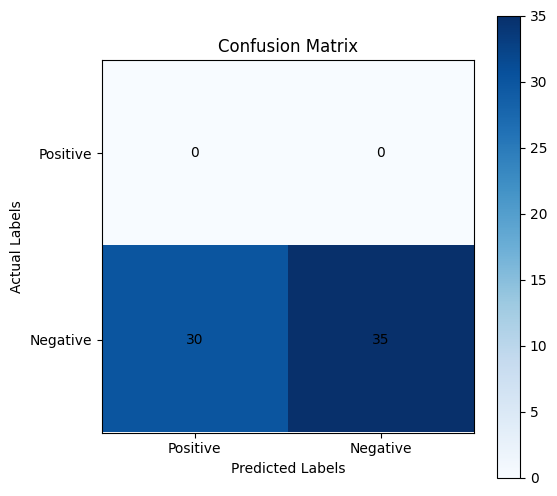

In [84]:
conf_matrix = np.array(data['metrics']['confusion_matrix'])


# Plot confusion matrix using Matplotlib
plt.figure(figsize=(6, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks(ticks=[0, 1], labels=['Positive', 'Negative'])
plt.yticks(ticks=[0, 1], labels=['Positive', 'Negative'])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')

# Annotate the cells with numbers
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, f'{conf_matrix[i, j]}', ha='center', va='center', color='black')

plt.show()

In [85]:
# Function to display a table of metrics
def display_metrics(epoch, loc_acc, ga, semsim):
    metrics = {
        "Metric": ["Localization Accuracy", "Grounding Accuracy", "Semantic Similarity"],
        "Value": [loc_acc, ga, semsim]
    }
    df_metrics = pd.DataFrame(metrics)
    print(f"\nEpoch: {epoch}\n")
    print(tabulate(df_metrics, headers="keys", tablefmt="pretty"))

# Function to display best and worst IoU cases as a table
def display_cases_table(cases, title):
    cases_data = []
    for case in cases:
        cases_data.append({
            "IoU": case["iou"],
            "Confidence": case["confidence"],
            "Image Path": case["path"],
            "Ground Truth": case["ground_truth"],
            "Candidate": case["candidate"]
        })
    df_cases = pd.DataFrame(cases_data)
    print(f"\n{title}\n")
    print(tabulate(df_cases, headers="keys", tablefmt="pretty"))

# Function to plot images with bounding boxes
def plot_image_with_boxes(image_path, ground_truth, candidate, title):
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    draw.rectangle(ground_truth, outline="green", width=3)
    draw.rectangle(candidate, outline="red", width=3)
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()

# Main function to display all information
def display_all_info(epoch, loc_acc, ga, semsim, best_cases, worst_cases, base_dir="."):
    # Display general metrics
    display_metrics(epoch, loc_acc, ga, semsim)
    
    # Display best IoU cases
    display_cases_table(best_cases, "Best IoU Cases")
    print("\nVisualizing Best IoU Cases:")

    plot_images_case(best_cases)
    
    # Display worst IoU cases
    display_cases_table(worst_cases, "Worst IoU Cases")
    print("\nVisualizing Worst IoU Cases:")
    plot_images_case(worst_cases)

In [86]:
best_cases_iou = data['best_cases_iou']
worst_cases_iou = data['worst_cases_iou']
best_cases_sim = data['best_cases_sim']
worst_cases_sim = data['worst_cases_sim']


Epoch: 1

+---+-----------------------+---------------------+
|   |        Metric         |        Value        |
+---+-----------------------+---------------------+
| 0 | Localization Accuracy | 0.5138979554176331  |
| 1 |  Grounding Accuracy   | 0.46153846153846156 |
| 2 |  Semantic Similarity  | 0.00554379727691412 |
+---+-----------------------+---------------------+

Best IoU Cases

+---+--------------------+----------------------+----------------------------------------------------+-------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|   |        IoU         |      Confidence      |                     Image Path                     |                                 Ground Truth                                  |                                   Candidate                                    |
+---+--------------------+----------------------+-------------------------------

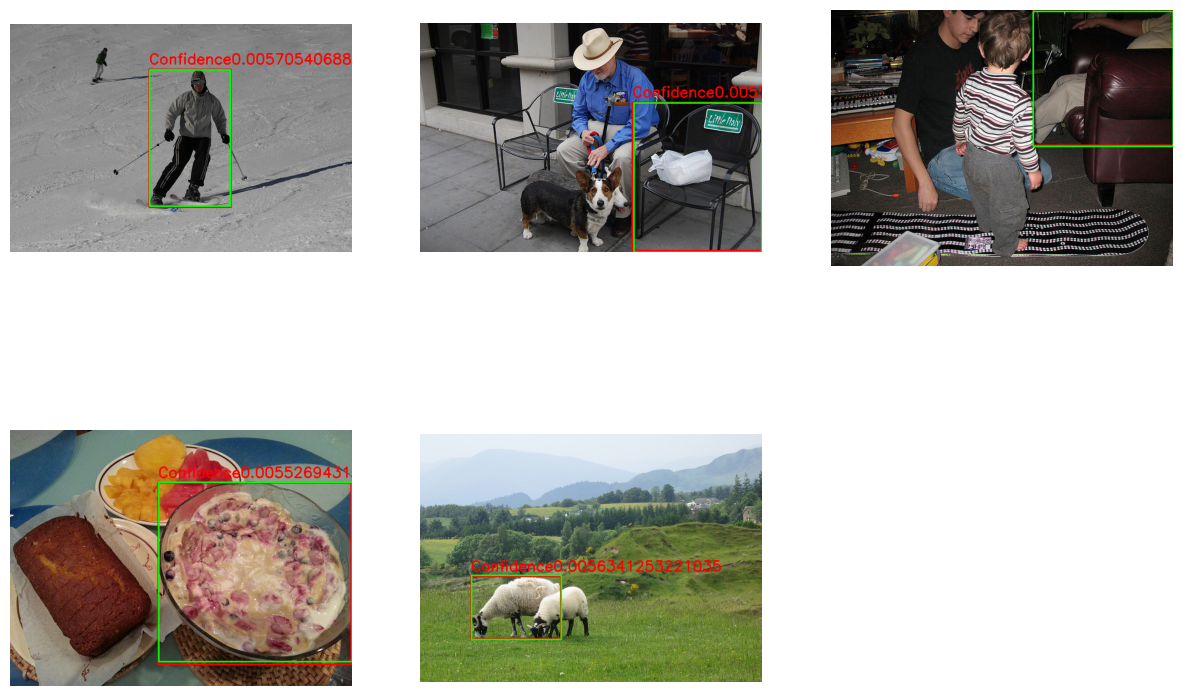


Worst IoU Cases

+---+-----+----------------------+----------------------------------------------------+---------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|   | IoU |      Confidence      |                     Image Path                     |                                  Ground Truth                                   |                                   Candidate                                    |
+---+-----+----------------------+----------------------------------------------------+---------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
| 0 | 0.0 | 0.005414469633251429 | ../refcocog/images/COCO_train2014_000000510027.jpg |  [380.5199890136719, 40.540000915527344, 555.8499755859375, 259.3999938964844]  |   [211.3123779296875, 310.5406494140625, 271.4971618652344,

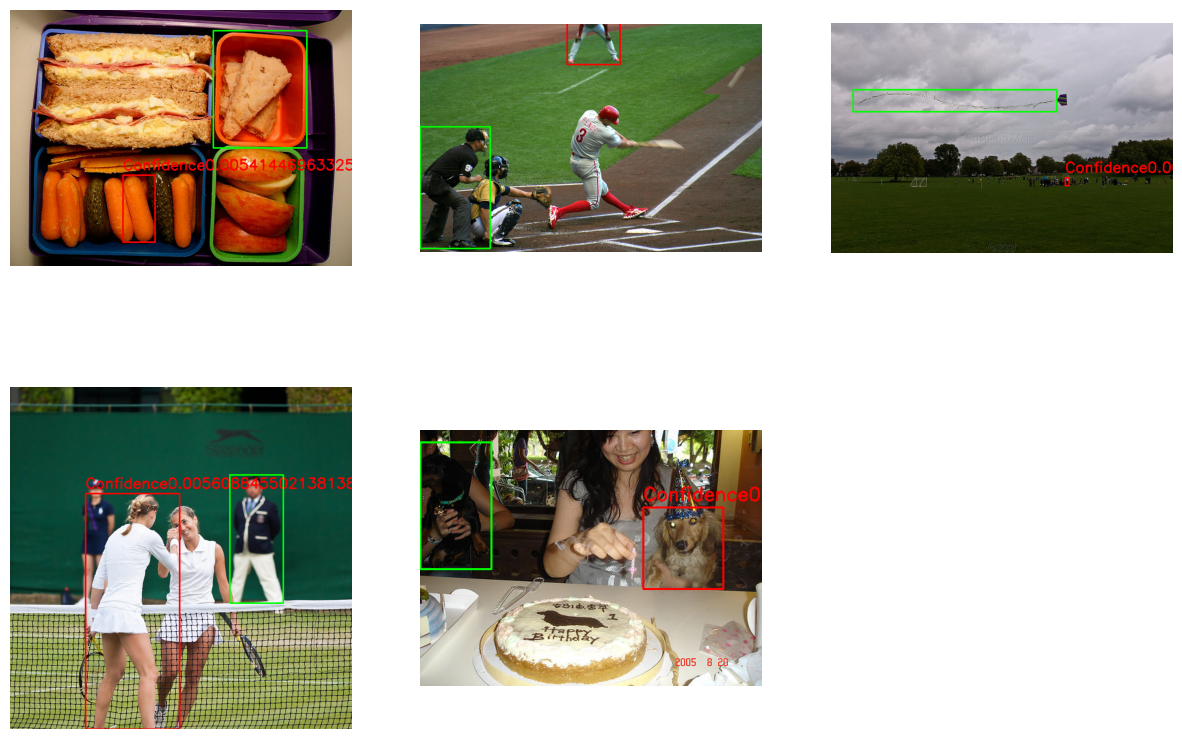

In [87]:
display_all_info(
    epoch=data['epoch'],
    loc_acc=data['metrics']['mean_iou'],
    ga=data['metrics']['grounding_accuracy'],
    semsim=data['metrics']['semantic_similarity'],
    best_cases=data['best_cases_iou'],
    worst_cases=data['worst_cases_iou'],
    base_dir="./refcocog"
)